In [1]:
!pip install -q \
    "transformers==4.48.3" \
    "datasets==3.2.0" \
    "accelerate==1.3.0" \
    "scikit-learn==1.5.2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 123.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.6/336.6 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 118.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 111.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is 

In [2]:
# Standard library
import os
import random

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.utils.class_weight import compute_class_weight

# PyTorch
import torch

# Hugging Face
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)

from pathlib import Path
import json
import shutil

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


For fine-tuning, I selected `bert-base-uncased` because the dataset is relatively small and the main priority is classification quality rather than training speed. BERT is a strong pretrained transformer model that can capture contextual meaning in support ticket texts better than traditional baseline models.


In [4]:
DATA_PATH = "/content/customer_support_tickets_cleaned.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Run the preprocessing notebook first or upload the cleaned CSV file."
    )

df = pd.read_csv(DATA_PATH)

df.head()

,text,subject,body,queue,priority,type,language
0,"Account Disruption Dear Customer Support Team,...",Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Technical Support,high,Incident,en
1,Query About Smart Home System Integration Feat...,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Returns and Exchanges,medium,Request,en
2,Inquiry Regarding Invoice Details Dear Custome...,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Billing and Payments,low,Request,en
3,Question About Marketing Agency Software Compa...,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Sales and Pre-Sales,medium,Problem,en
4,"Feature Query Dear Customer Support,\n\nI hope...",Feature Query,"Dear Customer Support,\n\nI hope this message ...",Technical Support,high,Request,en


In [5]:
df.shape

(23748, 7)

In [6]:
df[["text", "queue"]].isna().sum()

,0
text,0
queue,0


In [7]:
df["queue"].value_counts()

,count
queue,
Technical Support,6858
Product Support,4430
Customer Service,3570
IT Support,2833
Billing and Payments,2420
Returns and Exchanges,1173
Service Outages and Maintenance,937
Sales and Pre-Sales,724
Human Resources,461


### Class Distribution Conclusion

This distribution is consistent with the EDA findings from the first notebook. After filtering the dataset to English-language tickets and removing **4,513 exact duplicate texts (15.97%)**, the final modeling dataset contains **23,748 unique tickets**. However, removing duplicates did not eliminate the substantial target imbalance: `Technical Support` contains **6,858** examples, while `General Inquiry` contains only **342**, a difference of approximately 20×.

This imbalance influenced all subsequent modeling stages. The classical baseline notebook therefore used stratified splitting and Macro F1 as the principal selection metric, and the BERT experiment additionally uses class-weighted loss. Accuracy alone would be misleading because a model could achieve a relatively high score by favoring the dominant support queues while performing poorly on minority classes.

In [8]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["queue"])

In [9]:
pd.DataFrame({
    "Class": label_encoder.classes_,
    "Label": range(len(label_encoder.classes_))
})

,Class,Label
0,Billing and Payments,0
1,Customer Service,1
2,General Inquiry,2
3,Human Resources,3
4,IT Support,4
5,Product Support,5
6,Returns and Exchanges,6
7,Sales and Pre-Sales,7
8,Service Outages and Maintenance,8
9,Technical Support,9


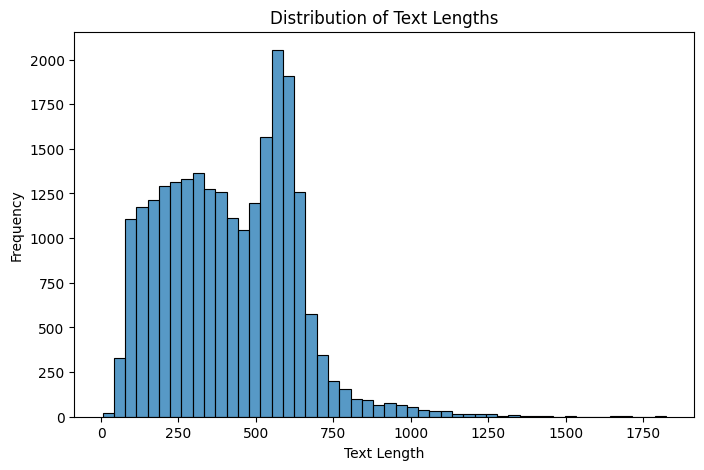

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df['text'].apply(len), bins=50)
plt.title('Distribution of Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

In [11]:
X = df["text"]
y = df["label"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=SEED,
    stratify=y_train
)

In [14]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [15]:
token_lengths = df["text"].astype(str).apply(
    lambda x: len(tokenizer.tokenize(x)) + 2
)

token_lengths.describe()

,text
count,23748.000000
mean,76.399360
std,40.030802
min,3.000000
25%,45.000000
50%,75.000000
75%,104.000000
max,419.000000


In [16]:
(token_lengths > 128).mean() * 100

np.float64(6.720565942395148)

In [17]:
max_length = 128

### Sequence Length Conclusion

The token-length analysis complements the text-length observations from the EDA notebook. The exploratory analysis showed that ticket bodies contain approximately **55 words on average**, while the BERT tokenizer produces a mean sequence length of about **76 tokens** and a median of **75 tokens**. In total, 75% of tickets contain no more than **104 tokens**, and only about **6.7%** exceed 128 tokens.

Therefore, `max_length = 128` is a reasonable efficiency–coverage compromise. It preserves the complete content of most tickets while reducing GPU memory usage and training time. Error rates were similar for the two largest groups containing up to 128 tokens. Longer tickets showed a somewhat higher error rate, but the corresponding groups were much smaller, so there is insufficient evidence that truncation is a primary performance bottleneck.

In [18]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding="max_length",
    max_length=max_length
)

val_encodings = tokenizer(
    X_val.tolist(),
    truncation=True,
    padding="max_length",
    max_length=max_length
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding="max_length",
    max_length=max_length
)

In [19]:
class TicketDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.reset_index(drop=True)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

In [20]:
train_dataset = TicketDataset(train_encodings, y_train)
val_dataset = TicketDataset(val_encodings, y_val)
test_dataset = TicketDataset(test_encodings, y_test)

In [21]:
train_dataset[0].keys()

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])

In [22]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, predictions)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "weighted_precision": precision_weighted,
        "weighted_recall": recall_weighted,
        "weighted_f1": f1_weighted
    }

In [23]:
classes = np.arange(len(label_encoder.classes_))

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train.to_numpy()
)

class_weights = torch.tensor(weights, dtype=torch.float32)


class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)

        if class_weights is None:
            raise ValueError("class_weights must be provided.")

        self.class_weights = class_weights

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        **kwargs,
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fn = torch.nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device)
        )

        loss = loss_fn(
            logits.view(-1, model.config.num_labels),
            labels.view(-1),
        )

        return (loss, outputs) if return_outputs else loss


print("Class weights:")
for label, weight in zip(label_encoder.classes_, class_weights.tolist()):
    print(f"{label}: {weight:.4f}")


Class weights:
Billing and Payments: 0.9810
Customer Service: 0.6653
General Inquiry: 6.9223
Human Resources: 5.1500
IT Support: 0.8385
Product Support: 0.5360
Returns and Exchanges: 2.0258
Sales and Pre-Sales: 3.2818
Service Outages and Maintenance: 2.5330
Technical Support: 0.3463


In [24]:
def create_training_args(output_dir):
    return TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",

        learning_rate=1e-5,
        warmup_ratio=0.1,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=5,
        weight_decay=0.05,

        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,

        logging_dir=f"{output_dir}/logs",
        logging_steps=100,

        save_total_limit=2,
        report_to="none",

        seed=SEED,
        data_seed=SEED,
        fp16=torch.cuda.is_available(),
    )


In [25]:
id2label = {
    i: label
    for i, label in enumerate(label_encoder.classes_)
}

label2id = {
    label: i
    for i, label in enumerate(label_encoder.classes_)
}

In [26]:
MODEL_NAME = "bert-base-uncased"


def create_model():
    set_seed(SEED)

    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(label_encoder.classes_),
        id2label=id2label,
        label2id=label2id,
    )


In [27]:
from copy import deepcopy
import gc


def run_experiment(
    experiment_name,
    trainer_class,
    use_class_weights=False,
):
    output_dir = f"./bert_ticket_router_{experiment_name}"
    training_args = create_training_args(output_dir)
    model = create_model()

    trainer_kwargs = {
        "model": model,
        "args": training_args,
        "train_dataset": train_dataset,
        "eval_dataset": val_dataset,
        "processing_class": tokenizer,
        "compute_metrics": compute_metrics,
        "callbacks": [
            EarlyStoppingCallback(
                early_stopping_patience=2,
                early_stopping_threshold=0.002,
            )
        ],
    }

    if use_class_weights:
        trainer_kwargs["class_weights"] = class_weights

    experiment_trainer = trainer_class(**trainer_kwargs)

    print(f"\nStarting experiment: {experiment_name}")
    train_result = experiment_trainer.train()

    train_predictions = experiment_trainer.predict(train_dataset)
    validation_metrics = experiment_trainer.evaluate()
    test_predictions = experiment_trainer.predict(test_dataset)


    candidate_dir = Path(f"/content/{experiment_name}_candidate_model")
    candidate_dir.mkdir(parents=True, exist_ok=True)
    experiment_trainer.save_model(str(candidate_dir))

    result = {
        "name": experiment_name,
        "candidate_dir": str(candidate_dir),
        "training_args": training_args,
        "train_result": train_result,
        "train_predictions": train_predictions,
        "validation_metrics": validation_metrics,
        "test_predictions": test_predictions,
        "trainer_state": deepcopy(experiment_trainer.state),
        "log_history": deepcopy(experiment_trainer.state.log_history),
    }


    experiment_trainer.model.to("cpu")
    del experiment_trainer
    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


In [28]:
assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)

assert len(train_dataset) > 0
assert len(val_dataset) > 0
assert len(test_dataset) > 0

assert df["text"].notna().all()
assert df["queue"].notna().all()

assert set(y_train.unique()) == set(range(len(label_encoder.classes_)))
assert set(y_val.unique()).issubset(set(y_train.unique()))
assert set(y_test.unique()).issubset(set(y_train.unique()))

assert torch.isfinite(class_weights).all()
assert (class_weights > 0).all()

print("Pre-training checks passed.")
print("Train examples:", len(train_dataset))
print("Validation examples:", len(val_dataset))
print("Test examples:", len(test_dataset))
print("Number of classes:", len(label_encoder.classes_))
print("Maximum sequence length:", max_length)


Pre-training checks passed.
Train examples: 17098
Validation examples: 1900
Test examples: 4750
Number of classes: 10
Maximum sequence length: 128


In [29]:
weighted_result = run_experiment(
    experiment_name="weighted",
    trainer_class=WeightedTrainer,
    use_class_weights=True,
)

unweighted_result = run_experiment(
    experiment_name="unweighted",
    trainer_class=Trainer,
    use_class_weights=False,
)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Starting experiment: weighted


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,1.866800,1.858166,0.343158,0.349850,0.301702,0.295088,0.354972,0.343158,0.335203
2,1.753300,1.725337,0.387895,0.430405,0.369294,0.365011,0.404821,0.387895,0.386459
3,1.547300,1.599989,0.377368,0.369058,0.429206,0.385576,0.400776,0.377368,0.373818
4,1.347200,1.606718,0.396842,0.435617,0.449632,0.428478,0.428863,0.396842,0.396908
5,1.155400,1.552895,0.414737,0.439321,0.474071,0.452332,0.422931,0.414737,0.413745


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Starting experiment: unweighted


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,1.653100,1.615782,0.407895,0.476960,0.251511,0.253599,0.429051,0.407895,0.347178
2,1.531800,1.528038,0.437895,0.453443,0.316272,0.343337,0.444004,0.437895,0.417405
3,1.368300,1.510116,0.436842,0.444190,0.357572,0.378678,0.444910,0.436842,0.431284
4,1.197000,1.478031,0.486842,0.564272,0.392639,0.417279,0.493782,0.486842,0.476470
5,1.014800,1.483972,0.493158,0.574755,0.396707,0.425436,0.502653,0.493158,0.484694


In [30]:
def prediction_metrics(prediction_output):
    logits = prediction_output.predictions

    if isinstance(logits, tuple):
        logits = logits[0]

    true_labels = prediction_output.label_ids
    predicted_labels = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(true_labels, predicted_labels),
        "macro_f1": f1_score(
            true_labels,
            predicted_labels,
            average="macro",
        ),
        "weighted_f1": f1_score(
            true_labels,
            predicted_labels,
            average="weighted",
        ),
    }


comparison_rows = []

for experiment_result in [weighted_result, unweighted_result]:
    train_metrics = prediction_metrics(
        experiment_result["train_predictions"]
    )
    test_metrics = prediction_metrics(
        experiment_result["test_predictions"]
    )
    validation = experiment_result["validation_metrics"]

    comparison_rows.append({
        "experiment": experiment_result["name"],
        "train_macro_f1": train_metrics["macro_f1"],
        "validation_accuracy": validation["eval_accuracy"],
        "validation_macro_f1": validation["eval_macro_f1"],
        "validation_weighted_f1": validation["eval_weighted_f1"],
        "test_accuracy": test_metrics["accuracy"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_weighted_f1": test_metrics["weighted_f1"],
        "best_epoch": experiment_result["trainer_state"].epoch,
        "best_checkpoint": experiment_result[
            "trainer_state"
        ].best_model_checkpoint,
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    "validation_macro_f1",
    ascending=False,
).reset_index(drop=True)

display(comparison_df)


,experiment,train_macro_f1,validation_accuracy,validation_macro_f1,validation_weighted_f1,test_accuracy,test_macro_f1,test_weighted_f1,best_epoch,best_checkpoint
0,weighted,0.651345,0.414737,0.452332,0.413745,0.428842,0.429677,0.429284,5.0,./bert_ticket_router_weighted/checkpoint-10690
1,unweighted,0.628395,0.493158,0.425436,0.484694,0.505474,0.425840,0.494927,5.0,./bert_ticket_router_unweighted/checkpoint-10690


In [31]:
selected_name = comparison_df.loc[0, "experiment"]

experiment_results = {
    "weighted": weighted_result,
    "unweighted": unweighted_result,
}

selected_result = experiment_results[selected_name]

print("Selected experiment:", selected_name)
print(
    "Selected validation Macro F1:",
    f"{selected_result['validation_metrics']['eval_macro_f1']:.4f}",
)

selected_model = AutoModelForSequenceClassification.from_pretrained(
    selected_result["candidate_dir"]
)

selected_training_args = create_training_args(
    "./bert_ticket_router_selected"
)

trainer = Trainer(
    model=selected_model,
    args=selected_training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)


trainer.state = deepcopy(selected_result["trainer_state"])

train_predictions = selected_result["train_predictions"]
validation_metrics = selected_result["validation_metrics"]
predictions = selected_result["test_predictions"]

train_prediction_metrics = prediction_metrics(train_predictions)
bert_train_f1_macro = train_prediction_metrics["macro_f1"]

print(f"Selected BERT Train F1 Macro: {bert_train_f1_macro:.4f}")

print("\nSelected validation metrics:")
for metric, value in validation_metrics.items():
    if isinstance(value, float):
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value}")


Selected experiment: weighted
Selected validation Macro F1: 0.4523
Selected BERT Train F1 Macro: 0.6513

Selected validation metrics:
eval_loss: 1.5529
eval_accuracy: 0.4147
eval_macro_precision: 0.4393
eval_macro_recall: 0.4741
eval_macro_f1: 0.4523
eval_weighted_precision: 0.4229
eval_weighted_recall: 0.4147
eval_weighted_f1: 0.4137
eval_runtime: 4.6625
eval_samples_per_second: 407.5060
eval_steps_per_second: 51.0450
epoch: 5.0000


In [32]:
for experiment_result in [weighted_result, unweighted_result]:
    history_df = pd.DataFrame(
        experiment_result["log_history"]
    )

    required_history_columns = [
        "epoch",
        "eval_loss",
        "eval_accuracy",
        "eval_macro_f1",
        "eval_weighted_f1",
    ]

    available_history_columns = [
        column
        for column in required_history_columns
        if column in history_df.columns
    ]

    print(f"\nHistory: {experiment_result['name']}")

    if "eval_macro_f1" in history_df.columns:
        eval_history = history_df[
            history_df["eval_macro_f1"].notna()
        ][available_history_columns]

        display(eval_history)
    else:
        print("No validation metrics were found.")

    print(
        "Best checkpoint:",
        experiment_result["trainer_state"].best_model_checkpoint,
    )
    print(
        "Best validation metric:",
        experiment_result["trainer_state"].best_metric,
    )



History: weighted


,epoch,eval_loss,eval_accuracy,eval_macro_f1,eval_weighted_f1
21,1.0,1.858166,0.343158,0.295088,0.335203
43,2.0,1.725337,0.387895,0.365011,0.386459
66,3.0,1.599989,0.377368,0.385576,0.373818
88,4.0,1.606718,0.396842,0.428478,0.396908
110,5.0,1.552895,0.414737,0.452332,0.413745
112,5.0,1.552895,0.414737,0.452332,0.413745


Best checkpoint: ./bert_ticket_router_weighted/checkpoint-10690
Best validation metric: 0.45233226574812047

History: unweighted


,epoch,eval_loss,eval_accuracy,eval_macro_f1,eval_weighted_f1
21,1.0,1.615782,0.407895,0.253599,0.347178
43,2.0,1.528038,0.437895,0.343337,0.417405
66,3.0,1.510116,0.436842,0.378678,0.431284
88,4.0,1.478031,0.486842,0.417279,0.476470
110,5.0,1.483972,0.493158,0.425436,0.484694
112,5.0,1.483972,0.493158,0.425436,0.484694


Best checkpoint: ./bert_ticket_router_unweighted/checkpoint-10690
Best validation metric: 0.42543633232054556


### Training and Validation Conclusion

The weighted BERT configuration was selected as the final model because it achieved the highest validation Macro F1: **0.4523**, compared with **0.4254** for the unweighted model. Applying class weights improved performance balance across the categories, although its overall validation accuracy was lower: **0.4147** versus **0.4932**.

For the selected model, Macro F1 reached **0.6513** on the training set and **0.4523** on the validation set. The resulting gap of approximately **0.1990** indicates moderate overfitting. However, validation Macro F1 consistently increased from **0.2951** after the first epoch to **0.4523** after the fifth epoch, so the results do not show a sharp deterioration in generalization during training.

Despite using contextual BERT representations, the model did not outperform the tuned TF-IDF + Linear SVM, which achieved a test Macro F1 of **0.5466** in the previous notebook. This suggests that the difficulty of the task is not determined by model architecture alone. Class imbalance, semantic overlap, and unclear boundaries between several ticket categories limit the model’s ability to distinguish the labels reliably.


In [33]:
logits = predictions.predictions

if isinstance(logits, tuple):
    logits = logits[0]

y_true = predictions.label_ids

probs = torch.softmax(
    torch.tensor(logits),
    dim=1,
).numpy()

y_pred = np.argmax(probs, axis=1)

bert_test_accuracy = accuracy_score(
    y_true,
    y_pred,
)

bert_test_macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
)

bert_test_weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
)

print("Selected experiment:", selected_name)
print(f"Test Accuracy: {bert_test_accuracy:.4f}")
print(f"Test Macro F1: {bert_test_macro_f1:.4f}")
print(f"Test Weighted F1: {bert_test_weighted_f1:.4f}")

pred_confidence = probs.max(axis=1)

sorted_probs = np.sort(probs, axis=1)
confidence_margin = (
    sorted_probs[:, -1]
    - sorted_probs[:, -2]
)

true_class_probability = probs[
    np.arange(len(y_true)),
    y_true,
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0,
    )
)


Selected experiment: weighted
Test Accuracy: 0.4288
Test Macro F1: 0.4297
Test Weighted F1: 0.4293
                                 precision    recall  f1-score   support

           Billing and Payments       0.77      0.79      0.78       484
               Customer Service       0.35      0.35      0.35       714
                General Inquiry       0.22      0.15      0.18        68
                Human Resources       0.45      0.47      0.46        92
                     IT Support       0.29      0.46      0.35       567
                Product Support       0.38      0.36      0.37       886
          Returns and Exchanges       0.41      0.39      0.40       235
            Sales and Pre-Sales       0.33      0.52      0.41       145
Service Outages and Maintenance       0.56      0.62      0.59       187
              Technical Support       0.49      0.36      0.41      1372

                       accuracy                           0.43      4750
                      m

In [34]:
bert_test_predictions = pd.DataFrame({
    "record_id": X_test.index.to_numpy(),
    "text": X_test.astype(str).to_numpy(),
    "true_label": label_encoder.inverse_transform(y_true),
    "bert_pred": label_encoder.inverse_transform(y_pred),
    "bert_confidence": pred_confidence,
    "bert_margin": confidence_margin,
    "true_class_probability": true_class_probability,
})

bert_test_predictions["bert_correct"] = (
    bert_test_predictions["bert_pred"]
    == bert_test_predictions["true_label"]
)

bert_test_predictions.to_csv(
    "bert_test_predictions.csv",
    index=False,
)

assert len(bert_test_predictions) == len(X_test)
assert bert_test_predictions["record_id"].is_unique
assert bert_test_predictions["true_label"].notna().all()
assert bert_test_predictions["bert_pred"].notna().all()

print("Rows:", len(bert_test_predictions))
print("Unique record IDs:", bert_test_predictions["record_id"].nunique())
print("File created successfully.")

Rows: 4750
Unique record IDs: 4750
File created successfully.


### Test-Set Conclusion and Baseline Comparison

On the held-out test set, the selected weighted BERT model achieved:

* **Accuracy: 0.4288**
* **Macro F1: 0.4297**
* **Weighted F1: 0.4293**

The strongest results were obtained for `Billing and Payments`, with an F1 score of **0.78**, and `Service Outages and Maintenance`, with an F1 score of **0.59**. The weakest-performing category was `General Inquiry`, with an F1 score of only **0.18**.

The tuned TF-IDF + Linear SVM model from the previous notebook achieved approximately **0.56 accuracy** and a test Macro F1 of **0.5466** on the same test split. Therefore, BERT underperformed the strongest classical baseline by approximately **0.117 Macro F1 points** and **13.1 percentage points in accuracy**.

These results demonstrate that TF-IDF features are highly effective for this dataset because several categories contain distinctive lexical signals associated with payments, returns, outages, and maintenance. BERT’s contextual representations did not sufficiently compensate for ambiguous class definitions, limited minority-class data, and potentially inconsistent annotations.


## Error Analysis

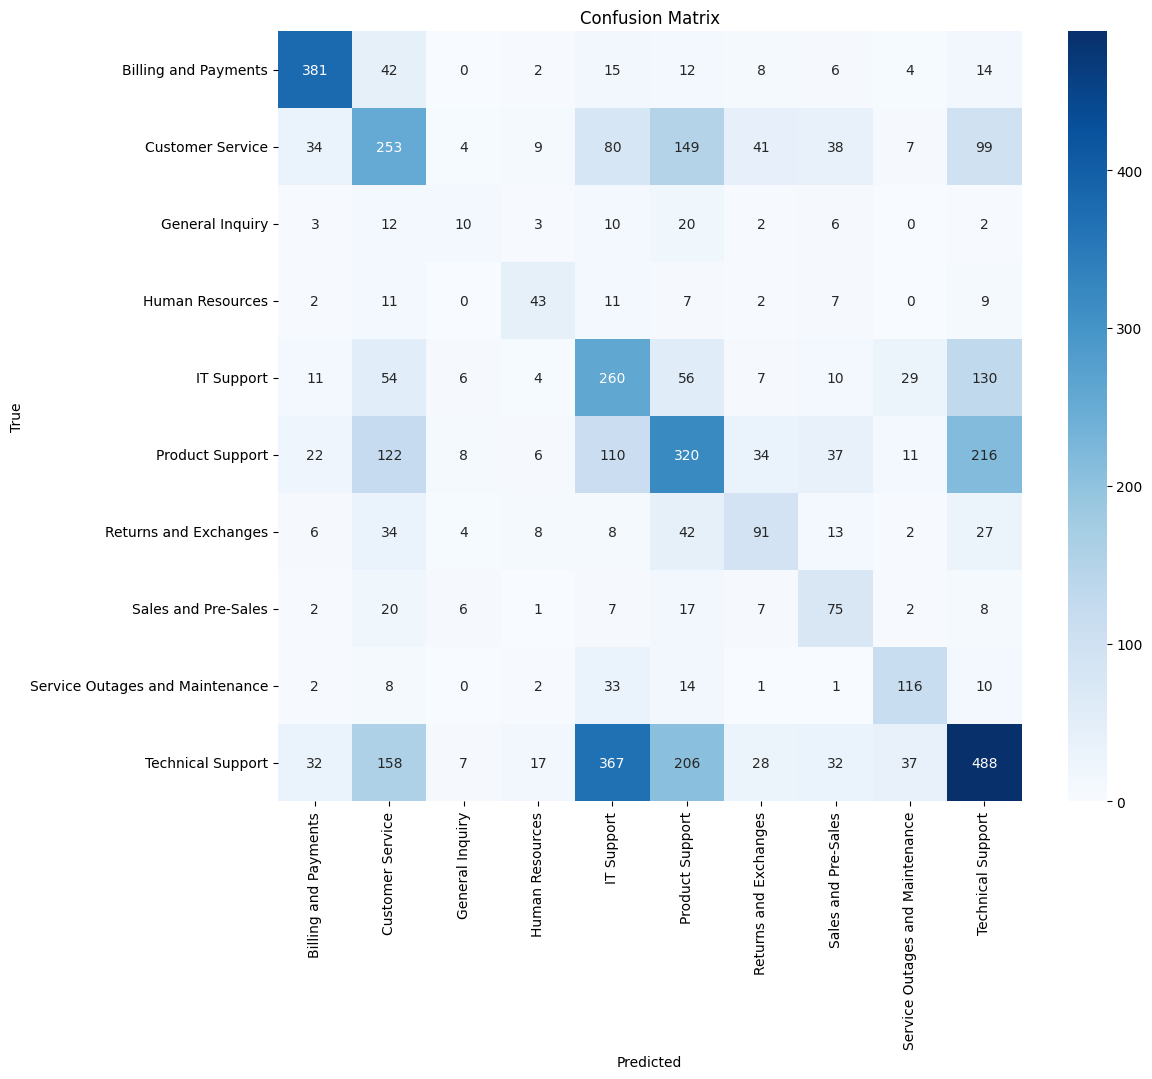

In [35]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [36]:
result_df = pd.DataFrame({
    "record_id": X_test.index.to_numpy(),
    "text": X_test.astype(str).to_numpy(),
    "true_label_id": y_true,
    "predicted_label_id": y_pred,
    "true_label": label_encoder.inverse_transform(y_true),
    "predicted_label": label_encoder.inverse_transform(y_pred),
    "is_error": y_true != y_pred,
    "pred_confidence": pred_confidence,
    "true_class_probability": true_class_probability,
    "confidence_margin": confidence_margin,
})

result_df.head()

,record_id,text,true_label_id,predicted_label_id,true_label,predicted_label,is_error,pred_confidence,true_class_probability,confidence_margin
0,19592,Issue with Login Sudden Cache Problem I have b...,4,9,IT Support,Technical Support,True,0.346841,0.315802,0.031039
1,15528,Problem with Sluggish System Performance An un...,1,4,Customer Service,IT Support,True,0.428917,0.024631,0.023619
2,23498,Query on Payment Options for Medical Data Serv...,0,0,Billing and Payments,Billing and Payments,False,0.991533,0.991533,0.988230
3,19877,Problem with Healthcare Data Encryption Incide...,9,9,Technical Support,Technical Support,False,0.503338,0.503338,0.288959
4,6360,Exploring Digital Strategies for Brand Growth ...,9,1,Technical Support,Customer Service,True,0.405044,0.034438,0.246426


In [37]:
total = len(result_df)
errors_count = result_df["is_error"].sum()
correct_count = total - errors_count

print("Total examples:", total)
print("Correct predictions:", correct_count)
print("Errors:", errors_count)
print("Error rate:", errors_count / total)

Total examples: 4750
Correct predictions: 2037
Errors: 2713
Error rate: 0.5711578947368421


In [38]:
per_class_errors = (
    result_df
    .groupby("true_label")
    .agg(
        total=("is_error", "size"),
        errors=("is_error", "sum"),
        avg_confidence=("pred_confidence", "mean")
    )
    .reset_index()
)

per_class_errors["error_rate"] = per_class_errors["errors"] / per_class_errors["total"]

per_class_errors = per_class_errors.sort_values("error_rate", ascending=False)

per_class_errors

,true_label,total,errors,avg_confidence,error_rate
2,General Inquiry,68,58,0.444782,0.852941
1,Customer Service,714,461,0.409660,0.645658
9,Technical Support,1372,884,0.435313,0.644315
5,Product Support,886,566,0.413808,0.638826
6,Returns and Exchanges,235,144,0.490696,0.612766
4,IT Support,567,307,0.472822,0.541446
3,Human Resources,92,49,0.605829,0.532609
7,Sales and Pre-Sales,145,70,0.599824,0.482759
8,Service Outages and Maintenance,187,71,0.729496,0.379679
0,Billing and Payments,484,103,0.799202,0.212810


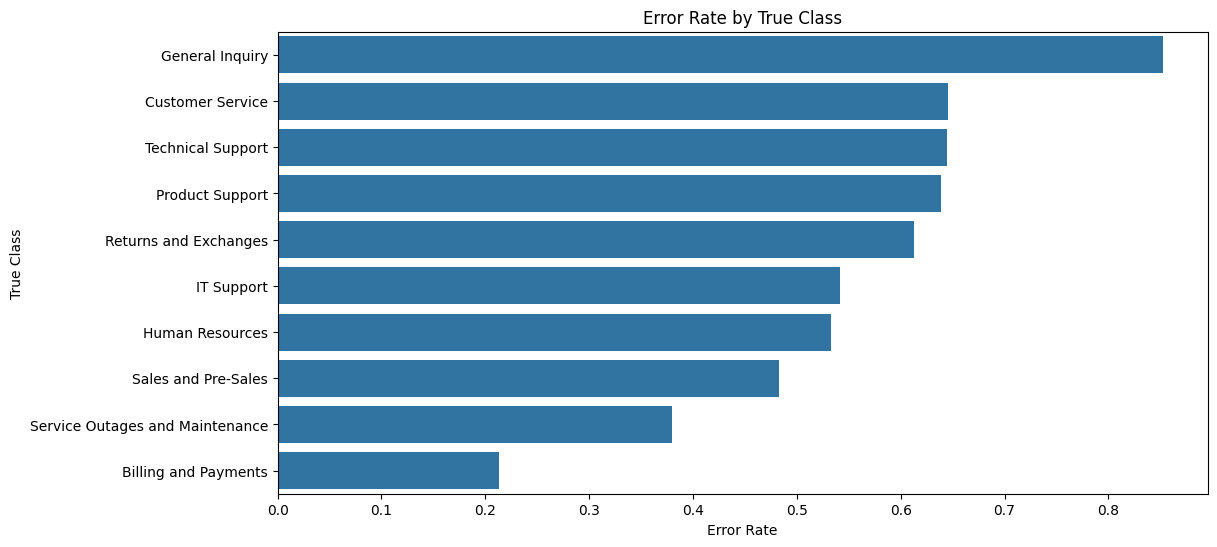

In [39]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=per_class_errors,
    x="error_rate",
    y="true_label"
)

plt.xlabel("Error Rate")
plt.ylabel("True Class")
plt.title("Error Rate by True Class")
plt.show()

In [40]:
errors_df = result_df[result_df["is_error"]].copy()

confusion_pairs = (
    errors_df
    .groupby(["true_label", "predicted_label"])
    .agg(
        count=("text", "size"),
        avg_confidence=("pred_confidence", "mean"),
        avg_true_class_probability=("true_class_probability", "mean")
    )
    .reset_index()
    .sort_values("count", ascending=False)
)

confusion_pairs.head(20)

,true_label,predicted_label,count,avg_confidence,avg_true_class_probability
80,Technical Support,IT Support,367,0.500073,0.258876
49,Product Support,Technical Support,216,0.395470,0.223226
81,Technical Support,Product Support,206,0.384310,0.210458
77,Technical Support,Customer Service,158,0.377635,0.136853
12,Customer Service,Product Support,149,0.388652,0.205001
40,IT Support,Technical Support,130,0.393333,0.215900
42,Product Support,Customer Service,122,0.353525,0.188223
45,Product Support,IT Support,110,0.455695,0.105097
16,Customer Service,Technical Support,99,0.380705,0.150192
11,Customer Service,IT Support,80,0.410554,0.110274


### Error-Analysis Conclusion

The overall BERT error rate on the test set was **57.1%**. The model correctly classified **2,037 of 4,750** examples and misclassified **2,713** examples.

The highest class-level error rates were observed for:

* `General Inquiry` — **85.3%**
* `Customer Service` — **64.6%**
* `Technical Support` — **64.4%**
* `Product Support` — **63.9%**

The most frequent confusion pairs were:

* `Technical Support → IT Support` — **367 cases**
* `Product Support → Technical Support` — **216 cases**
* `Technical Support → Product Support` — **206 cases**
* `Technical Support → Customer Service` — **158 cases**
* `Customer Service → Product Support` — **149 cases**

This error structure confirms that semantic overlap among the broad support categories is a major limitation. Similar confusion patterns were also observed for the Linear SVM, so the errors cannot be attributed solely to the limitations of either TF-IDF or BERT.

The error rates were similar for the two largest sequence-length groups: **57.3%** for tickets containing up to 64 tokens and **56.5%** for tickets containing 65–128 tokens. Tickets containing 129–256 tokens had a higher error rate of **62.0%**, but this group contained only **258 examples**. The 257–512-token group contained only **nine examples**, which is too small to support reliable conclusions.

Overall, there is insufficient evidence that `max_length = 128` or truncation is the primary cause of the model’s limited performance.

The results instead point to structural dataset limitations, including class imbalance, insufficient minority-class examples, semantic overlap, and potentially inconsistent labeling. Consequently, label auditing and taxonomy improvement are likely to provide greater performance gains than additional BERT hyperparameter tuning alone.


In [41]:
def show_errors(true_class=None, predicted_class=None, n=10):
    subset = errors_df.copy()

    if true_class is not None:
        subset = subset[subset["true_label"] == true_class]

    if predicted_class is not None:
        subset = subset[subset["predicted_label"] == predicted_class]

    subset = subset.sort_values("pred_confidence", ascending=False)

    return subset[[
        "text",
        "true_label",
        "predicted_label",
        "pred_confidence",
        "true_class_probability",
        "confidence_margin"
    ]].head(n)

In [42]:
show_errors(
    true_class="Customer Service",
    predicted_class="Product Support",
    n=10
)

,text,true_label,predicted_label,pred_confidence,true_class_probability,confidence_margin
698,"Recent Feedback on Delayed Responses Recently,...",Customer Service,Product Support,0.579856,0.158214,0.421641
732,Irregular Investment Performance Indicators Am...,Customer Service,Product Support,0.572922,0.179225,0.393698
4510,Marketing Campaigns Successful The digital cam...,Customer Service,Product Support,0.559847,0.137733,0.395805
699,Strategies for Brand Growth Have Hit a Standst...,Customer Service,Product Support,0.558087,0.112720,0.429858
2647,Digital Campaigns Underperformance in the Quar...,Customer Service,Product Support,0.541824,0.182021,0.359803
4259,Decline in Digital Marketing Campaign to Boost...,Customer Service,Product Support,0.536644,0.148730,0.387914
1690,Underwhelming Results of Digital Campaigns Due...,Customer Service,Product Support,0.525942,0.217539,0.308403
104,Assistance Needed for Sluggish Dashboard Acces...,Customer Service,Product Support,0.524502,0.186652,0.337850
1342,Assistance Required for Marketing Campaign Enh...,Customer Service,Product Support,0.523431,0.184281,0.339150
3725,Problem with Concurrent Integration Failures D...,Customer Service,Product Support,0.522839,0.122379,0.312622


In [43]:
show_errors(
    true_class="General Inquiry",
    n=10
)

,text,true_label,predicted_label,pred_confidence,true_class_probability,confidence_margin
702,Problem with Hospital System Security breach f...,General Inquiry,Human Resources,0.899554,0.008589,0.866947
3539,Promptly Inform User About Onboarding Process ...,General Inquiry,Human Resources,0.897176,0.028910,0.868266
1163,Request for Integration of Advanced Data Analy...,General Inquiry,Sales and Pre-Sales,0.829909,0.100091,0.729817
1771,Inquiry on Security Features of Intel Optane M...,General Inquiry,Sales and Pre-Sales,0.819561,0.029977,0.772642
3504,Inquiry About SaaS Features for Project Tracki...,General Inquiry,Returns and Exchanges,0.701924,0.024255,0.545304
1841,Revise User Interface Submitting a request to ...,General Inquiry,IT Support,0.701748,0.018968,0.559040
2743,"Dear Customer Support, we are encountering is...",General Inquiry,IT Support,0.694531,0.006390,0.489628
4358,"Dear Customer Support, we are encountering is...",General Inquiry,IT Support,0.660245,0.006283,0.427570
3280,"Dear Customer Support Team,<br><br>I am reach...",General Inquiry,Sales and Pre-Sales,0.619884,0.061677,0.485693
4279,Investigation Needed for Inaccurate Investment...,General Inquiry,Product Support,0.569666,0.034894,0.407882


In [44]:
result_df["char_length"] = result_df["text"].astype(str).apply(len)
result_df["token_length"] = result_df["text"].astype(str).apply(
    lambda x: len(tokenizer.tokenize(x))
)

length_analysis = (
    result_df
    .assign(length_group=pd.cut(
        result_df["token_length"],
        bins=[0, 64, 128, 256, 512, 10000],
        labels=["0-64", "65-128", "129-256", "257-512", "512+"]
    ))
    .groupby("length_group", observed=False)
    .agg(
        total=("is_error", "size"),
        errors=("is_error", "sum"),
        avg_confidence=("pred_confidence", "mean")
    )
    .reset_index()
)

length_analysis["error_rate"] = length_analysis["errors"] / length_analysis["total"]

length_analysis

,length_group,total,errors,avg_confidence,error_rate
0,0-64,2089,1198,0.479806,0.573480
1,65-128,2394,1353,0.503865,0.565163
2,129-256,258,160,0.474051,0.620155
3,257-512,9,2,0.566126,0.222222
4,512+,0,0,NaN,NaN


### Final Integrated Conclusion

The EDA stage established that the original English-language subset contained **28,261 records**, including **4,513 duplicate ticket texts**, representing **15.97%** of the data. Removing the duplicates produced **23,748 unique tickets** and reduced the risk of train–test leakage. The analysis also revealed class imbalance and substantial semantic overlap among several support categories.

The tuned TF-IDF + Linear SVM pipeline was the strongest model in the current experiments, achieving approximately **56% test accuracy** and a Macro F1 score of **0.5466**. This indicates that distinctive words and short phrases provide strong predictive signals for many ticket categories.

The weighted BERT model achieved **42.88% test accuracy**, a Macro F1 score of **0.4297**, and a Weighted F1 score of **0.4293**. It performed well on categories with distinctive terminology, particularly `Billing and Payments` and `Service Outages and Maintenance`, but it did not reliably distinguish between `Customer Service`, `Product Support`, `IT Support`, and `Technical Support`.

Therefore, the tuned Linear SVM should be retained as the primary model for the current version of the dataset. The BERT experiment remains valuable because it demonstrates that increasing model complexity does not guarantee better performance when label quality and class separability are the main bottlenecks.


The central conclusion is that future performance improvements are more likely to result from better data quality and label design than from model complexity alone.


## Save the Fine-Tuned BERT Model

In [45]:
MODEL_DIR = Path("/content/bert_ticket_router_model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(MODEL_DIR))

tokenizer.save_pretrained(str(MODEL_DIR))

label_mapping = {
    "id2label": {
        str(index): label
        for index, label in enumerate(label_encoder.classes_)
    },
    "label2id": {
        label: int(index)
        for index, label in enumerate(label_encoder.classes_)
    },
}

with open(
    MODEL_DIR / "label_mapping.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        label_mapping,
        file,
        ensure_ascii=False,
        indent=2,
    )


trainer.state.save_to_json(
    str(MODEL_DIR / "trainer_state.json")
)


inference_config = {
    "base_model": "bert-base-uncased",
    "max_length": int(max_length),
    "num_labels": int(len(label_encoder.classes_)),
    "seed": int(SEED),
    "text_column": "text",
    "label_column": "label",
}

with open(
    MODEL_DIR / "inference_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        inference_config,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Saved model directory:")
print(MODEL_DIR)

print("\nSaved files:")
for path in sorted(MODEL_DIR.iterdir()):
    print("-", path.name)


Saved model directory:
/content/bert_ticket_router_model

Saved files:
- config.json
- inference_config.json
- label_mapping.json
- model.safetensors
- special_tokens_map.json
- tokenizer.json
- tokenizer_config.json
- trainer_state.json
- training_args.bin
- vocab.txt


In [46]:
MODEL_ARCHIVE = shutil.make_archive(
    "/content/bert_ticket_router_model",
    "zip",
    root_dir=MODEL_DIR,
)

print("Created model archive:")
print(MODEL_ARCHIVE)


from google.colab import files

files.download(MODEL_ARCHIVE)

Created model archive:
/content/bert_ticket_router_model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
reloaded_tokenizer = AutoTokenizer.from_pretrained(
    str(MODEL_DIR)
)

reloaded_model = AutoModelForSequenceClassification.from_pretrained(
    str(MODEL_DIR)
)

assert reloaded_model.config.num_labels == len(label_encoder.classes_)

print("Model and tokenizer were reloaded successfully.")
print("Number of labels:", reloaded_model.config.num_labels)

Model and tokenizer were reloaded successfully.
Number of labels: 10


In [48]:
required_objects = [
    "trainer",
    "train_dataset",
    "val_dataset",
    "test_dataset",
    "y_true",
    "y_pred",
    "result_df",
]

for object_name in required_objects:
    assert object_name in globals(), f"{object_name} was not created"

assert len(y_true) == len(y_test)
assert len(y_pred) == len(y_test)
assert len(result_df) == len(y_test)

print("Notebook pipeline completed successfully.")

Notebook pipeline completed successfully.
